# Advection-ridge semivariogram diagnostic

This notebook implements a 2D space-time empirical semivariogram diagnostic for the GEMS TCO advection model.

The old diagnostic slices the empirical cross-semivariogram along latitude or longitude only. Here we compute

```text
gamma_hat(h_lat, h_lon, tau)
  = 0.5 * mean{ r(s, t) - r(s + h, t + tau) }^2
```

on the full 2D lag plane. The fitted advection model predicts that the low-semivariance basin should move roughly along

```text
h_star(tau) ~= advection * tau
```

So the main plot overlays the empirical ridge/minimum and the fitted advection vector.

Reference notebook: `empirical_sem_raw_scale_052126.ipynb`.


## Notes on coordinates

This implementation defaults to `keep_ori=False`, meaning it uses regular `Latitude/Longitude` grid coordinates. That lets us compute 2D lag surfaces by fast grid shifts instead of constructing an `N x N` pair matrix.

Use `keep_ori=True` only after adding a tolerance/KD-tree pair matcher for exact source coordinates. The current fast grid-shift implementation is intentionally built for the regular grid version.


## Status: exploratory, not inferential yet

This notebook is a diagnostic prototype. It is rigorous as a deterministic calculation of a stated empirical quantity, but it is **not** yet a rigorous statistical test.

Important limitations:

```text
1. It uses regular grid coordinates by default (`keep_ori=False`), not exact source locations.
2. It uses hourly-mean-centered values, not full GLS/model residuals.
3. The ridge is a smoothed argmin, so uncertainty is not shown.
4. Missingness/cloud patterns can move the apparent minimum.
5. Missingness/cloud patterns can move the apparent minimum.
```

Sign convention used here:

```text
empirical h = future location - current location
model distance uses x - v * delta_t
therefore expected ridge is h = v * tau
```

So the default overlay is `+advection*tau`. A publishable version should add bootstrap or simulation envelopes and should compute the same diagnostic on model residuals.


In [1]:
# Core imports
import os
import sys
import math
import pickle
import json
from pathlib import Path
from typing import Dict, Iterable, Optional, Sequence, Tuple

PROJECT_ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib_cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.ndimage import gaussian_filter

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = PROJECT_ROOT / 'plots' / 'directional_semivariograms' / 'advection_ridge_052526'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output directory: {OUTPUT_DIR}')


Output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526


In [2]:
# User settings
YEAR = 2024
MONTH = 7

# Same region as the existing semivariogram scripts.
LAT_RANGE = [-3.0, 2.0]
LON_RANGE = [121.0, 131.0]

# Use regular grid coordinates for fast 2D lag shifts.
KEEP_ORI = False

TARGET_DAY = 1       # 1-based day number in July
TAUS = [1, 2, 3]     # temporal lags in hourly-slot units

# Lag grid in integer grid-cell offsets. With July 2024 grid this is about
# 0.044 deg latitude and 0.063 deg longitude per offset.
MAX_LAT_OFFSET = 20
MAX_LON_OFFSET = 20
LAG_OFFSET_STRIDE = 1   # set to 2 for faster rough scans

CENTER_MODE = 'hourly_mean'  # {'hourly_mean', 'none'}
SMOOTH_SIGMA = 1.0
MIN_PAIR_COUNT = 1_000

# Empirical h is future location minus current location.
# With model distance x - v * delta_t, the expected ridge is h = v * tau.
# Add a negative-sign entry here only for debugging sign conventions.
MODEL_OVERLAY_SIGNS = {
    'fitted advection * tau': 1.0,
}

# The model overlay uses the selected daily fitted estimate CSV.
ESTIMATE_CSV = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/july_22_23_24_25/real_vecc_july_22_23_24_25_mm20.csv')


In [3]:
loader = load_data_dynamic_processed(config.mac_data_load_path)

df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    years_=[str(YEAR)],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)

print(f'Loaded {len(df_map)} hourly maps')
print(f'Monthly mean used by loader: {monthly_mean:.4f}')
print('First keys:', sorted(df_map)[:3])


--- Global Monthly Mean for 2024-7: 257.9726 ---
Loaded 248 hourly maps
Monthly mean used by loader: 257.9726
First keys: ['2024_07_y24m07day01_hm00:53', '2024_07_y24m07day01_hm01:53', '2024_07_y24m07day01_hm02:53']


In [4]:
def load_day_map(day: int, keep_ori: bool = KEEP_ORI) -> Dict[str, torch.Tensor]:
    """Load one 1-based day into the same hourly tensor-map structure used elsewhere."""
    day_token = f'day{int(day):02d}'
    day_keys = [k for k in sorted(df_map) if day_token in k]
    if not day_keys:
        raise ValueError(f'No keys found for {day_token}')

    subset = {k: df_map[k] for k in day_keys}
    day_map, _ = loader.load_working_data(
        coarse_dicts=subset,
        monthly_mean=monthly_mean,
        idx_for_datamap=[0, len(day_keys)],
        ord_mm=None,
        dtype=torch.float64,
        keep_ori=keep_ori,
    )
    return day_map


def as_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def infer_grid_from_tensor(tensor, digits: int = 6) -> Tuple[np.ndarray, np.ndarray]:
    arr = as_numpy(tensor)
    lats = np.sort(np.unique(np.round(arr[:, 0], digits)))
    lons = np.sort(np.unique(np.round(arr[:, 1], digits)))
    return lats, lons


def tensor_to_grid(
    tensor,
    lats: np.ndarray,
    lons: np.ndarray,
    value_col: int = 2,
    digits: int = 6,
) -> np.ndarray:
    """Convert [lat, lon, value, ...] rows to a dense lat x lon grid with NaNs."""
    arr = as_numpy(tensor)
    lat_to_i = {float(v): i for i, v in enumerate(lats)}
    lon_to_j = {float(v): j for j, v in enumerate(lons)}
    grid = np.full((len(lats), len(lons)), np.nan, dtype=float)

    rounded_lats = np.round(arr[:, 0], digits)
    rounded_lons = np.round(arr[:, 1], digits)
    vals = arr[:, value_col].astype(float)

    for lat, lon, val in zip(rounded_lats, rounded_lons, vals):
        i = lat_to_i.get(float(lat))
        j = lon_to_j.get(float(lon))
        if i is not None and j is not None:
            grid[i, j] = val
    return grid


def build_hourly_grids(
    day_map: Dict[str, torch.Tensor],
    center_mode: str = CENTER_MODE,
    digits: int = 6,
):
    """Return sorted keys, centered hourly grids, coordinate vectors, and grid steps."""
    keys = sorted(day_map)
    lats, lons = infer_grid_from_tensor(day_map[keys[0]], digits=digits)
    grids = []

    for key in keys:
        grid = tensor_to_grid(day_map[key], lats, lons, digits=digits)
        if center_mode == 'hourly_mean':
            grid = grid - np.nanmean(grid)
        elif center_mode == 'none':
            pass
        else:
            raise ValueError(f'Unknown center_mode: {center_mode}')
        grids.append(grid)

    lat_step = float(np.nanmedian(np.diff(lats)))
    lon_step = float(np.nanmedian(np.diff(lons)))
    return keys, grids, lats, lons, lat_step, lon_step


def make_lag_offsets(
    max_lat_offset: int = MAX_LAT_OFFSET,
    max_lon_offset: int = MAX_LON_OFFSET,
    stride: int = LAG_OFFSET_STRIDE,
) -> Tuple[np.ndarray, np.ndarray]:
    lat_offsets = np.arange(-max_lat_offset, max_lat_offset + 1, stride, dtype=int)
    lon_offsets = np.arange(-max_lon_offset, max_lon_offset + 1, stride, dtype=int)
    if 0 not in lat_offsets:
        lat_offsets = np.sort(np.append(lat_offsets, 0))
    if 0 not in lon_offsets:
        lon_offsets = np.sort(np.append(lon_offsets, 0))
    return lat_offsets, lon_offsets


def shifted_sum_half_sq(cur: np.ndarray, nxt: np.ndarray, di: int, dj: int) -> Tuple[float, int]:
    """Compute 0.5 * sum(diff^2) and n for Z(s,t) - Z(s+h,t+tau)."""
    nlat, nlon = cur.shape

    if abs(di) >= nlat or abs(dj) >= nlon:
        return 0.0, 0

    if di >= 0:
        cur_i = slice(0, nlat - di)
        nxt_i = slice(di, nlat)
    else:
        cur_i = slice(-di, nlat)
        nxt_i = slice(0, nlat + di)

    if dj >= 0:
        cur_j = slice(0, nlon - dj)
        nxt_j = slice(dj, nlon)
    else:
        cur_j = slice(-dj, nlon)
        nxt_j = slice(0, nlon + dj)

    cur_view = cur[cur_i, cur_j]
    nxt_view = nxt[nxt_i, nxt_j]
    mask = np.isfinite(cur_view) & np.isfinite(nxt_view)
    n = int(mask.sum())
    if n == 0:
        return 0.0, 0

    diff = cur_view[mask] - nxt_view[mask]
    return float(0.5 * np.sum(diff * diff)), n


def compute_advection_ridge_surfaces(
    day_map: Dict[str, torch.Tensor],
    taus: Sequence[int] = TAUS,
    lat_offsets: Optional[np.ndarray] = None,
    lon_offsets: Optional[np.ndarray] = None,
    center_mode: str = CENTER_MODE,
    hour_indices: Optional[Sequence[int]] = None,
    verbose: bool = True,
):
    """Compute pooled 2D cross-semivariogram surfaces for one day."""
    if lat_offsets is None or lon_offsets is None:
        lat_offsets, lon_offsets = make_lag_offsets()

    keys, grids, lats, lons, lat_step, lon_step = build_hourly_grids(day_map, center_mode=center_mode)
    lat_offsets = np.asarray(lat_offsets, dtype=int)
    lon_offsets = np.asarray(lon_offsets, dtype=int)

    if hour_indices is None:
        hour_indices = list(range(len(grids)))

    surfaces = {}
    for tau in taus:
        tau = int(tau)
        starts = [h for h in hour_indices if h + tau < len(grids)]
        if not starts:
            raise ValueError(f'No valid hour pairs for tau={tau}')

        sum_half_sq = np.zeros((len(lat_offsets), len(lon_offsets)), dtype=float)
        counts = np.zeros_like(sum_half_sq, dtype=int)

        for h in starts:
            cur = grids[h]
            nxt = grids[h + tau]
            for ii, di in enumerate(lat_offsets):
                for jj, dj in enumerate(lon_offsets):
                    ss, n = shifted_sum_half_sq(cur, nxt, int(di), int(dj))
                    if n > 0:
                        sum_half_sq[ii, jj] += ss
                        counts[ii, jj] += n

        gamma = np.full_like(sum_half_sq, np.nan, dtype=float)
        valid = counts > 0
        gamma[valid] = sum_half_sq[valid] / counts[valid]

        surfaces[tau] = {
            'gamma': gamma,
            'counts': counts,
            'lat_offsets': lat_offsets,
            'lon_offsets': lon_offsets,
            'lat_lags': lat_offsets * lat_step,
            'lon_lags': lon_offsets * lon_step,
            'lat_step': lat_step,
            'lon_step': lon_step,
            'hour_starts': starts,
            'keys': keys,
            'center_mode': center_mode,
        }
        if verbose:
            print(
                f'tau={tau}: gamma shape={gamma.shape}, '
                f'finite={np.isfinite(gamma).sum()}, '
                f'n_pairs range=({counts[counts > 0].min()}, {counts.max()})'
            )

    return surfaces


In [5]:
def nan_gaussian_filter(arr: np.ndarray, sigma: float = SMOOTH_SIGMA) -> np.ndarray:
    """Gaussian smoothing with NaN-aware normalized convolution."""
    mask = np.isfinite(arr)
    if not mask.any():
        return np.full_like(arr, np.nan, dtype=float)
    vals = gaussian_filter(np.where(mask, arr, 0.0), sigma=sigma, mode='nearest')
    weights = gaussian_filter(mask.astype(float), sigma=sigma, mode='nearest')
    out = vals / np.maximum(weights, 1e-12)
    out[weights <= 1e-12] = np.nan
    return out


def extract_ridge(
    surface: Dict,
    smooth_sigma: float = SMOOTH_SIGMA,
    min_pair_count: int = MIN_PAIR_COUNT,
) -> Dict[str, float]:
    """Extract smoothed minimum location from one tau surface."""
    gamma = np.asarray(surface['gamma'], dtype=float)
    counts = np.asarray(surface['counts'], dtype=int)
    smoothed = nan_gaussian_filter(gamma, sigma=smooth_sigma)
    candidate = np.where(counts >= min_pair_count, smoothed, np.nan)

    if not np.isfinite(candidate).any():
        return {
            'lat_lag': np.nan,
            'lon_lag': np.nan,
            'gamma_min': np.nan,
            'n_pairs': 0,
            'row': -1,
            'col': -1,
        }

    flat_idx = int(np.nanargmin(candidate))
    row, col = np.unravel_index(flat_idx, candidate.shape)
    return {
        'lat_lag': float(surface['lat_lags'][row]),
        'lon_lag': float(surface['lon_lags'][col]),
        'gamma_min': float(candidate[row, col]),
        'n_pairs': int(counts[row, col]),
        'row': int(row),
        'col': int(col),
    }



def load_estimates(estimate_csv: Path = ESTIMATE_CSV, year: int = YEAR) -> Optional[pd.DataFrame]:
    """Load daily fitted parameters and parse year/month/day from the day column."""
    candidates = [Path(estimate_csv)]
    yy = int(year) % 100
    candidates.extend(sorted((PROJECT_ROOT / 'outputs' / 'day').glob(f'**/real_dw_july{yy:02d}.csv')))
    candidates.extend(sorted((PROJECT_ROOT / 'outputs' / 'day').glob(f'**/real_vecc_july{yy:02d}*.csv')))

    seen = set()
    for path in candidates:
        path = Path(path)
        if path in seen:
            continue
        seen.add(path)
        if path.exists():
            df = pd.read_csv(path)
            if 'day' in df.columns:
                parsed = df['day'].astype(str).str.extract(r'(?P<year>\d{4})-(?P<month>\d{1,2})-(?P<day_num>\d{1,2})')
                for col in ['year', 'month', 'day_num']:
                    df[col] = pd.to_numeric(parsed[col], errors='coerce').astype('Int64')
            print(f'Loaded estimates: {path}')
            return df

    print('No estimate CSV found. Model overlay will be skipped.')
    return None


def get_estimate_row(
    estimates_df: Optional[pd.DataFrame],
    day: int,
    year: int = YEAR,
    month: int = MONTH,
) -> Optional[pd.Series]:
    if estimates_df is None or estimates_df.empty:
        return None
    needed = {'year', 'month', 'day_num'}
    if needed.issubset(estimates_df.columns):
        match = estimates_df.loc[
            (estimates_df['year'].astype(float) == int(year))
            & (estimates_df['month'].astype(float) == int(month))
            & (estimates_df['day_num'].astype(float) == int(day))
        ]
        if not match.empty:
            return match.iloc[0]
    if 'day_num' in estimates_df.columns:
        match = estimates_df.loc[estimates_df['day_num'].astype(float) == int(day)]
        if not match.empty:
            return match.iloc[0]
    return None

def model_advection_points(
    row: Optional[pd.Series],
    tau: int,
    signs: Optional[Dict[str, float]] = None,
) -> Dict[str, Tuple[float, float]]:
    if signs is None:
        signs = MODEL_OVERLAY_SIGNS
    if row is None:
        return {}
    needed = {'advec_lat', 'advec_lon'}
    if not needed.issubset(row.index):
        return {}

    base_lon = float(row['advec_lon']) * tau
    base_lat = float(row['advec_lat']) * tau
    return {label: (sign * base_lon, sign * base_lat) for label, sign in signs.items()}


In [6]:
def _surface_plot_limits(surfaces: Dict[int, Dict], min_pair_count: int = MIN_PAIR_COUNT):
    vals = []
    for surface in surfaces.values():
        gamma = surface['gamma']
        counts = surface['counts']
        use = gamma[(counts >= min_pair_count) & np.isfinite(gamma)]
        if use.size:
            vals.append(use)
    if not vals:
        return None, None
    vals = np.concatenate(vals)
    return float(np.nanpercentile(vals, 2)), float(np.nanpercentile(vals, 98))


def plot_advection_ridge_surfaces(
    surfaces: Dict[int, Dict],
    day: int = TARGET_DAY,
    estimates_df: Optional[pd.DataFrame] = None,
    smooth_sigma: float = SMOOTH_SIGMA,
    min_pair_count: int = MIN_PAIR_COUNT,
    save: bool = False,
):
    taus = list(surfaces.keys())
    n = len(taus)
    fig, axes = plt.subplots(1, n, figsize=(6.0 * n, 5.2), constrained_layout=True)
    axes = np.atleast_1d(axes)

    vmin, vmax = _surface_plot_limits(surfaces, min_pair_count=min_pair_count)
    row = get_estimate_row(estimates_df, day)

    last_im = None
    ridge_rows = []
    for ax, tau in zip(axes, taus):
        surface = surfaces[tau]
        gamma = np.where(surface['counts'] >= min_pair_count, surface['gamma'], np.nan)
        smoothed = nan_gaussian_filter(gamma, sigma=smooth_sigma)
        extent = [
            float(surface['lon_lags'][0]), float(surface['lon_lags'][-1]),
            float(surface['lat_lags'][0]), float(surface['lat_lags'][-1]),
        ]
        last_im = ax.imshow(
            smoothed,
            origin='lower',
            extent=extent,
            aspect='auto',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        ax.axhline(0, color='white', lw=0.8, alpha=0.6)
        ax.axvline(0, color='white', lw=0.8, alpha=0.6)

        ridge = extract_ridge(surface, smooth_sigma=smooth_sigma, min_pair_count=min_pair_count)
        ridge_rows.append({'tau': tau, **ridge})
        ax.scatter(
            ridge['lon_lag'], ridge['lat_lag'],
            marker='x', s=90, lw=2.5, color='crimson', label='empirical ridge'
        )

        model_points = model_advection_points(row, tau)
        marker_specs = {
            'fitted advection * tau': dict(marker='*', color='white', edgecolor='black', s=180),
        }
        for label, (model_lon, model_lat) in model_points.items():
            spec = marker_specs.get(label, dict(marker='o', color='white', edgecolor='black', s=120))
            ax.scatter(
                model_lon, model_lat,
                linewidth=1.0, label=label, **spec
            )
            ax.arrow(
                0, 0, model_lon, model_lat,
                length_includes_head=True, head_width=0.035, head_length=0.045,
                color='white', alpha=0.55, linewidth=1.1
            )

        ax.set_title(
            f'Day {day}, tau={tau}\n'
            f"ridge=({ridge['lon_lag']:.3f}, {ridge['lat_lag']:.3f})"
        )
        ax.set_xlabel('longitude lag')
        ax.set_ylabel('latitude lag')
        ax.legend(loc='upper right', fontsize=8, frameon=True)

    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.85, label='smoothed empirical semivariance')

    ridge_df = pd.DataFrame(ridge_rows)
    if save:
        path = OUTPUT_DIR / f'advection_ridge_surfaces_day{day:02d}.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
    return fig, axes, ridge_df


def plot_pair_counts(
    surfaces: Dict[int, Dict],
    day: int = TARGET_DAY,
    save: bool = False,
):
    taus = list(surfaces.keys())
    n = len(taus)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.8), constrained_layout=True)
    axes = np.atleast_1d(axes)

    last_im = None
    for ax, tau in zip(axes, taus):
        surface = surfaces[tau]
        counts = surface['counts'].astype(float)
        extent = [
            float(surface['lon_lags'][0]), float(surface['lon_lags'][-1]),
            float(surface['lat_lags'][0]), float(surface['lat_lags'][-1]),
        ]
        last_im = ax.imshow(counts, origin='lower', extent=extent, aspect='auto', cmap='mako')
        ax.axhline(0, color='white', lw=0.8, alpha=0.6)
        ax.axvline(0, color='white', lw=0.8, alpha=0.6)
        ax.set_title(f'n pairs, tau={tau}')
        ax.set_xlabel('longitude lag')
        ax.set_ylabel('latitude lag')

    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.85, label='number of pairs')

    if save:
        path = OUTPUT_DIR / f'advection_ridge_pair_counts_day{day:02d}.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
    return fig, axes


def plot_asymmetry_surfaces(
    surfaces: Dict[int, Dict],
    day: int = TARGET_DAY,
    min_pair_count: int = MIN_PAIR_COUNT,
    save: bool = False,
):
    taus = list(surfaces.keys())
    n = len(taus)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.8), constrained_layout=True)
    axes = np.atleast_1d(axes)

    asym_list = []
    for surface in surfaces.values():
        gamma = np.where(surface['counts'] >= min_pair_count, surface['gamma'], np.nan)
        asym = gamma - np.flipud(np.fliplr(gamma))
        asym_list.append(asym)
    finite = np.concatenate([a[np.isfinite(a)] for a in asym_list if np.isfinite(a).any()])
    lim = float(np.nanpercentile(np.abs(finite), 98)) if finite.size else 1.0

    last_im = None
    for ax, tau, asym in zip(axes, taus, asym_list):
        surface = surfaces[tau]
        extent = [
            float(surface['lon_lags'][0]), float(surface['lon_lags'][-1]),
            float(surface['lat_lags'][0]), float(surface['lat_lags'][-1]),
        ]
        last_im = ax.imshow(
            asym,
            origin='lower',
            extent=extent,
            aspect='auto',
            cmap='coolwarm',
            vmin=-lim,
            vmax=lim,
        )
        ax.axhline(0, color='black', lw=0.7, alpha=0.6)
        ax.axvline(0, color='black', lw=0.7, alpha=0.6)
        ax.set_title(f'gamma(h,tau)-gamma(-h,tau), tau={tau}')
        ax.set_xlabel('longitude lag')
        ax.set_ylabel('latitude lag')

    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.85, label='odd/asymmetry semivariance')

    if save:
        path = OUTPUT_DIR / f'advection_ridge_asymmetry_day{day:02d}.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
    return fig, axes


In [7]:
def metric_collapse_dataframe(
    surfaces: Dict[int, Dict],
    estimates_df: Optional[pd.DataFrame],
    day: int = TARGET_DAY,
    min_pair_count: int = MIN_PAIR_COUNT,
) -> pd.DataFrame:
    row = get_estimate_row(estimates_df, day)
    if row is None:
        raise ValueError('No fitted parameter row found for this day.')

    needed = ['range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon']
    missing = [c for c in needed if c not in row.index]
    if missing:
        raise ValueError(f'Estimate row is missing columns: {missing}')

    range_lat = float(row['range_lat'])
    range_lon = float(row['range_lon'])
    range_time = float(row['range_time'])
    advec_lat = float(row['advec_lat'])
    advec_lon = float(row['advec_lon'])

    rows = []
    for tau, surface in surfaces.items():
        lat_mesh, lon_mesh = np.meshgrid(surface['lat_lags'], surface['lon_lags'], indexing='ij')
        d_fit = np.sqrt(
            ((lat_mesh - advec_lat * tau) / range_lat) ** 2
            + ((lon_mesh - advec_lon * tau) / range_lon) ** 2
            + (tau / range_time) ** 2
        )
        gamma = surface['gamma']
        counts = surface['counts']
        mask = (counts >= min_pair_count) & np.isfinite(gamma) & np.isfinite(d_fit)
        tmp = pd.DataFrame({
            'tau': tau,
            'lat_lag': lat_mesh[mask],
            'lon_lag': lon_mesh[mask],
            'd_fit': d_fit[mask],
            'gamma': gamma[mask],
            'n_pairs': counts[mask],
        })
        rows.append(tmp)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def weighted_mean(x, value_col='gamma', weight_col='n_pairs'):
    w = x[weight_col].to_numpy(dtype=float)
    v = x[value_col].to_numpy(dtype=float)
    if np.sum(w) <= 0:
        return np.nan
    return float(np.average(v, weights=w))


def plot_metric_collapse(
    collapse_df: pd.DataFrame,
    day: int = TARGET_DAY,
    n_bins: int = 30,
    save: bool = False,
):
    if collapse_df.empty:
        raise ValueError('collapse_df is empty')

    upper = float(collapse_df['d_fit'].quantile(0.98))
    bins = np.linspace(0, upper, n_bins + 1)
    df = collapse_df.loc[collapse_df['d_fit'] <= upper].copy()
    df['d_bin'] = pd.cut(df['d_fit'], bins=bins, include_lowest=True)

    binned_rows = []
    for (tau, d_bin), x in df.groupby(['tau', 'd_bin'], observed=True):
        binned_rows.append({
            'tau': tau,
            'd_bin': d_bin,
            'd_mid': float(np.average(x['d_fit'], weights=x['n_pairs'])),
            'gamma_wmean': weighted_mean(x),
            'n_pairs': int(x['n_pairs'].sum()),
        })
    binned = pd.DataFrame(binned_rows)

    fig, ax = plt.subplots(figsize=(8.5, 6.0), constrained_layout=True)
    sns.scatterplot(
        data=df.sample(min(len(df), 4_000), random_state=4),
        x='d_fit', y='gamma', hue='tau', palette='viridis',
        alpha=0.25, s=18, edgecolor=None, ax=ax,
    )
    sns.lineplot(
        data=binned,
        x='d_mid', y='gamma_wmean', hue='tau', palette='viridis',
        marker='o', linewidth=2.2, ax=ax, legend=False,
    )
    ax.set_title(f'Metric-collapse diagnostic, day {day}')
    ax.set_xlabel('fitted advection-aware distance')
    ax.set_ylabel('empirical semivariance')

    if save:
        path = OUTPUT_DIR / f'advection_metric_collapse_day{day:02d}.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
    return fig, ax, binned


In [8]:
def compare_ridge_to_fitted_advection(
    ridge_df: pd.DataFrame,
    estimates_df: Optional[pd.DataFrame],
    day: int = TARGET_DAY,
    signs: Optional[Dict[str, float]] = None,
    save: bool = False,
) -> pd.DataFrame:
    """Quantify empirical ridge displacement against fitted advection displacement."""
    if signs is None:
        signs = MODEL_OVERLAY_SIGNS
    row = get_estimate_row(estimates_df, day)
    if row is None:
        raise ValueError('No fitted parameter row found for this day.')

    base_lat = float(row['advec_lat'])
    base_lon = float(row['advec_lon'])
    out = []
    for _, r in ridge_df.iterrows():
        tau = int(r['tau'])
        for label, sign in signs.items():
            model_lat = sign * base_lat * tau
            model_lon = sign * base_lon * tau
            err_lat = float(r['lat_lag']) - model_lat
            err_lon = float(r['lon_lag']) - model_lon
            err_euclid = float(np.sqrt(err_lat**2 + err_lon**2))
            out.append({
                'day': day,
                'tau': tau,
                'comparison': label,
                'ridge_lat_lag': float(r['lat_lag']),
                'ridge_lon_lag': float(r['lon_lag']),
                'model_lat_lag': model_lat,
                'model_lon_lag': model_lon,
                'err_lat': err_lat,
                'err_lon': err_lon,
                'err_euclid': err_euclid,
                'ridge_gamma_min': float(r['gamma_min']),
                'ridge_n_pairs': int(r['n_pairs']),
                'advec_lat_daily': base_lat,
                'advec_lon_daily': base_lon,
            })
    comp = pd.DataFrame(out)
    if save:
        path = OUTPUT_DIR / f'ridge_vs_fitted_advection_day{day:02d}.csv'
        comp.to_csv(path, index=False)
        print(f'Saved {path}')
    return comp


def plot_ridge_vs_fitted_advection(
    comparison_df: pd.DataFrame,
    day: int = TARGET_DAY,
    save: bool = False,
):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)

    # Lag plane path comparison.
    ax = axes[0]
    emp = comparison_df.drop_duplicates('tau').sort_values('tau')
    ax.plot(emp['ridge_lon_lag'], emp['ridge_lat_lag'], '-x', color='crimson', lw=2.5, ms=9, label='empirical ridge')

    for label, grp in comparison_df.groupby('comparison'):
        grp = grp.sort_values('tau')
        marker = '*' if label.startswith('+') else '^'
        ax.plot(grp['model_lon_lag'], grp['model_lat_lag'], '--', lw=1.8, marker=marker, ms=9, label=label)

    ax.axhline(0, color='0.7', lw=1)
    ax.axvline(0, color='0.7', lw=1)
    ax.set_xlabel('longitude lag')
    ax.set_ylabel('latitude lag')
    ax.set_title(f'Ridge path vs fitted displacement, day {day}')
    ax.legend(fontsize=9)
    ax.set_aspect('equal', adjustable='box')

    # Euclidean error by tau/sign.
    ax = axes[1]
    sns.lineplot(
        data=comparison_df,
        x='tau', y='err_euclid', hue='comparison',
        marker='o', linewidth=2.2, ax=ax,
    )
    ax.set_title('Distance between empirical ridge and model displacement')
    ax.set_xlabel('tau')
    ax.set_ylabel('Euclidean lag error')
    ax.grid(True, alpha=0.3)

    if save:
        path = OUTPUT_DIR / f'ridge_vs_fitted_advection_day{day:02d}.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved {path}')
    return fig, axes


## Run one day

This cell computes the 2D lag surfaces for `TARGET_DAY`. With `LAG_OFFSET_STRIDE=1` the surface is fairly detailed; set it to `2` for faster rough scans.


In [9]:
lat_offsets, lon_offsets = make_lag_offsets(
    max_lat_offset=MAX_LAT_OFFSET,
    max_lon_offset=MAX_LON_OFFSET,
    stride=LAG_OFFSET_STRIDE,
)
print(f'lat offsets: {lat_offsets[0]}..{lat_offsets[-1]} ({len(lat_offsets)} bins)')
print(f'lon offsets: {lon_offsets[0]}..{lon_offsets[-1]} ({len(lon_offsets)} bins)')

day_map = load_day_map(TARGET_DAY, keep_ori=KEEP_ORI)
surfaces = compute_advection_ridge_surfaces(
    day_map,
    taus=TAUS,
    lat_offsets=lat_offsets,
    lon_offsets=lon_offsets,
    center_mode=CENTER_MODE,
    verbose=True,
)

first_surface = surfaces[TAUS[0]]
print('Grid step lat/lon:', first_surface['lat_step'], first_surface['lon_step'])
print('Physical lag ranges:')
print('  lat:', first_surface['lat_lags'][0], first_surface['lat_lags'][-1])
print('  lon:', first_surface['lon_lags'][0], first_surface['lon_lags'][-1])


lat offsets: -20..20 (41 bins)
lon offsets: -20..20 (41 bins)
tau=1: gamma shape=(41, 41), finite=1681, n_pairs range=(71333, 106293)
tau=2: gamma shape=(41, 41), finite=1681, n_pairs range=(59199, 86768)
tau=3: gamma shape=(41, 41), finite=1681, n_pairs range=(48826, 71052)
Grid step lat/lon: 0.04400000000000004 0.06300000000000239
Physical lag ranges:
  lat: -0.8800000000000008 0.8800000000000008
  lon: -1.2600000000000477 1.2600000000000477


In [10]:
estimates_df = load_estimates(ESTIMATE_CSV, year=YEAR)
if estimates_df is not None:
    display(estimates_df.head())
    display(estimates_df.loc[(estimates_df['year'].astype(float) == YEAR) & (estimates_df['month'].astype(float) == MONTH) & (estimates_df['day_num'].astype(float) == TARGET_DAY)])


Loaded estimates: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/july_22_23_24_25/real_vecc_july_22_23_24_25_mm20.csv


,day,cov_name,space_size,lr,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget,loss,time,rmsre,year,month,day_num
0,2022-07-1,Vecc_mm100_A20B20C20,18126.0,1.0,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723,1.2591,54.4569,0.0,2022,7,1
1,2022-07-2,Vecc_mm100_A20B20C20,18126.0,1.0,7.8296,0.3299,0.3572,1.6104,0.0263,-0.1932,2.6110,1.3469,39.9762,0.0,2022,7,2
2,2022-07-3,Vecc_mm100_A20B20C20,18126.0,1.0,10.2319,0.3491,0.5161,1.8609,0.0359,-0.1294,2.2946,1.3337,33.3842,0.0,2022,7,3
3,2022-07-4,Vecc_mm100_A20B20C20,18126.0,1.0,8.4243,0.3425,0.3735,2.0497,0.0135,-0.1327,2.9670,1.3877,44.1352,0.0,2022,7,4
4,2022-07-5,Vecc_mm100_A20B20C20,18126.0,1.0,7.6151,0.3265,0.3837,2.0529,0.0222,-0.1464,1.9366,1.2492,31.3534,0.0,2022,7,5


,day,cov_name,space_size,lr,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget,loss,time,rmsre,year,month,day_num
56,2024-07-1,Vecc_mm100_A20B20C20,18126.0,1.0,13.5816,0.3276,0.3979,1.9409,-0.0099,-0.1725,1.4232,1.344,32.0127,0.0,2024,7,1


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526/advection_ridge_surfaces_day01.png


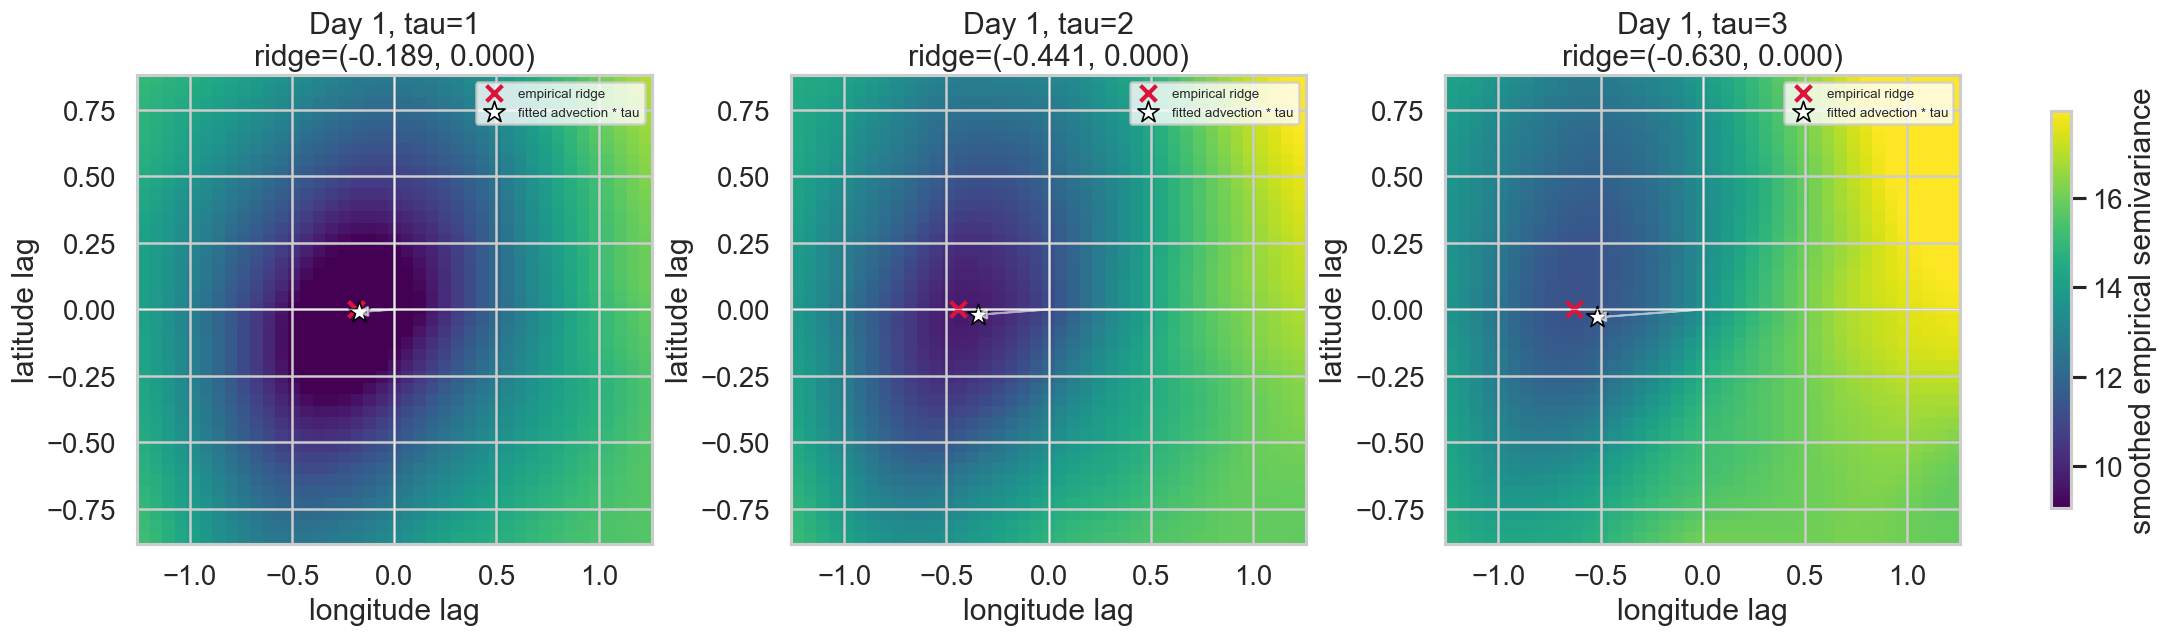

,tau,lat_lag,lon_lag,gamma_min,n_pairs,row,col
0,1,0.0,-0.189,7.255031,104917,20,17
1,2,0.0,-0.441,9.673078,83197,20,13
2,3,0.0,-0.630,11.339004,66041,20,10


In [11]:
fig, axes, ridge_df = plot_advection_ridge_surfaces(
    surfaces,
    day=TARGET_DAY,
    estimates_df=estimates_df,
    smooth_sigma=SMOOTH_SIGMA,
    min_pair_count=MIN_PAIR_COUNT,
    save=True,
)
plt.show()

ridge_df


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526/ridge_vs_fitted_advection_day01.csv


,day,tau,comparison,ridge_lat_lag,ridge_lon_lag,model_lat_lag,model_lon_lag,err_lat,err_lon,err_euclid,ridge_gamma_min,ridge_n_pairs,advec_lat_daily,advec_lon_daily
0,1,1,fitted advection * tau,0.0,-0.189,-0.0099,-0.1725,0.0099,-0.0165,0.019242,7.255031,104917,-0.0099,-0.1725
1,1,2,fitted advection * tau,0.0,-0.441,-0.0198,-0.3450,0.0198,-0.0960,0.098021,9.673078,83197,-0.0099,-0.1725
2,1,3,fitted advection * tau,0.0,-0.630,-0.0297,-0.5175,0.0297,-0.1125,0.116354,11.339004,66041,-0.0099,-0.1725


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526/ridge_vs_fitted_advection_day01.png


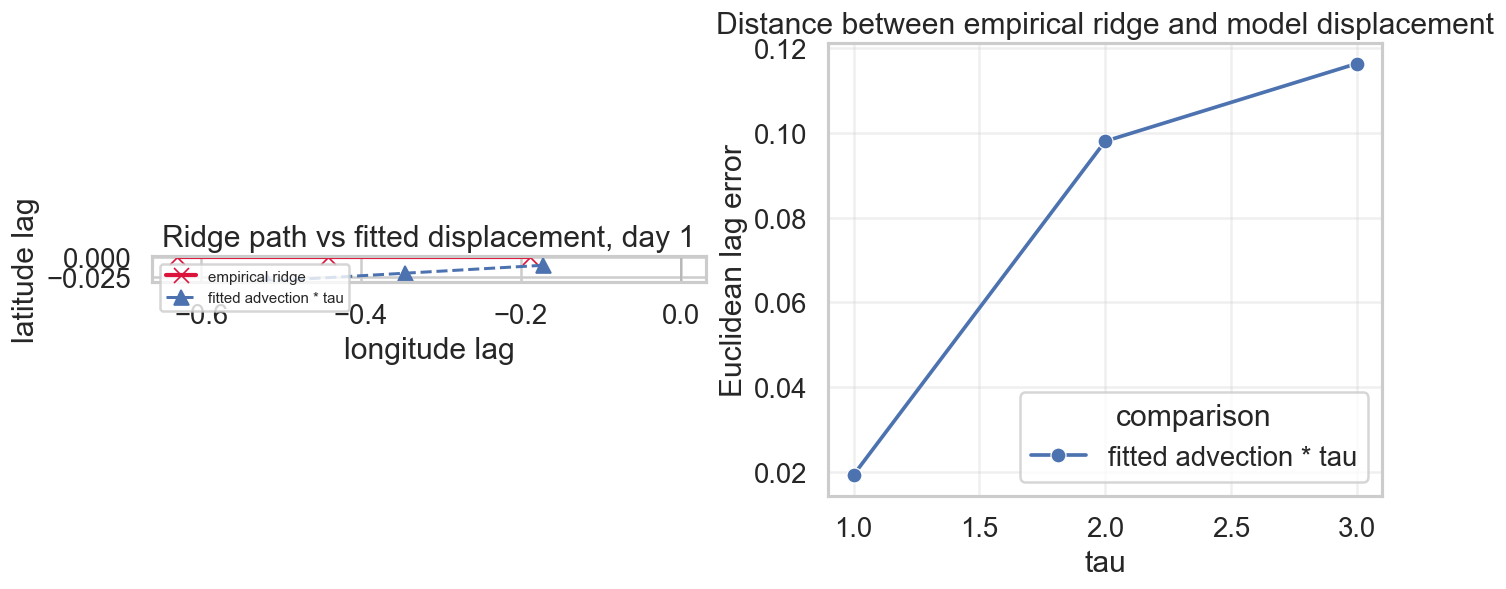

In [12]:
ridge_model_comparison = compare_ridge_to_fitted_advection(
    ridge_df,
    estimates_df=estimates_df,
    day=TARGET_DAY,
    save=True,
)

display(ridge_model_comparison)

fig, axes = plot_ridge_vs_fitted_advection(
    ridge_model_comparison,
    day=TARGET_DAY,
    save=True,
)
plt.show()


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526/advection_ridge_pair_counts_day01.png


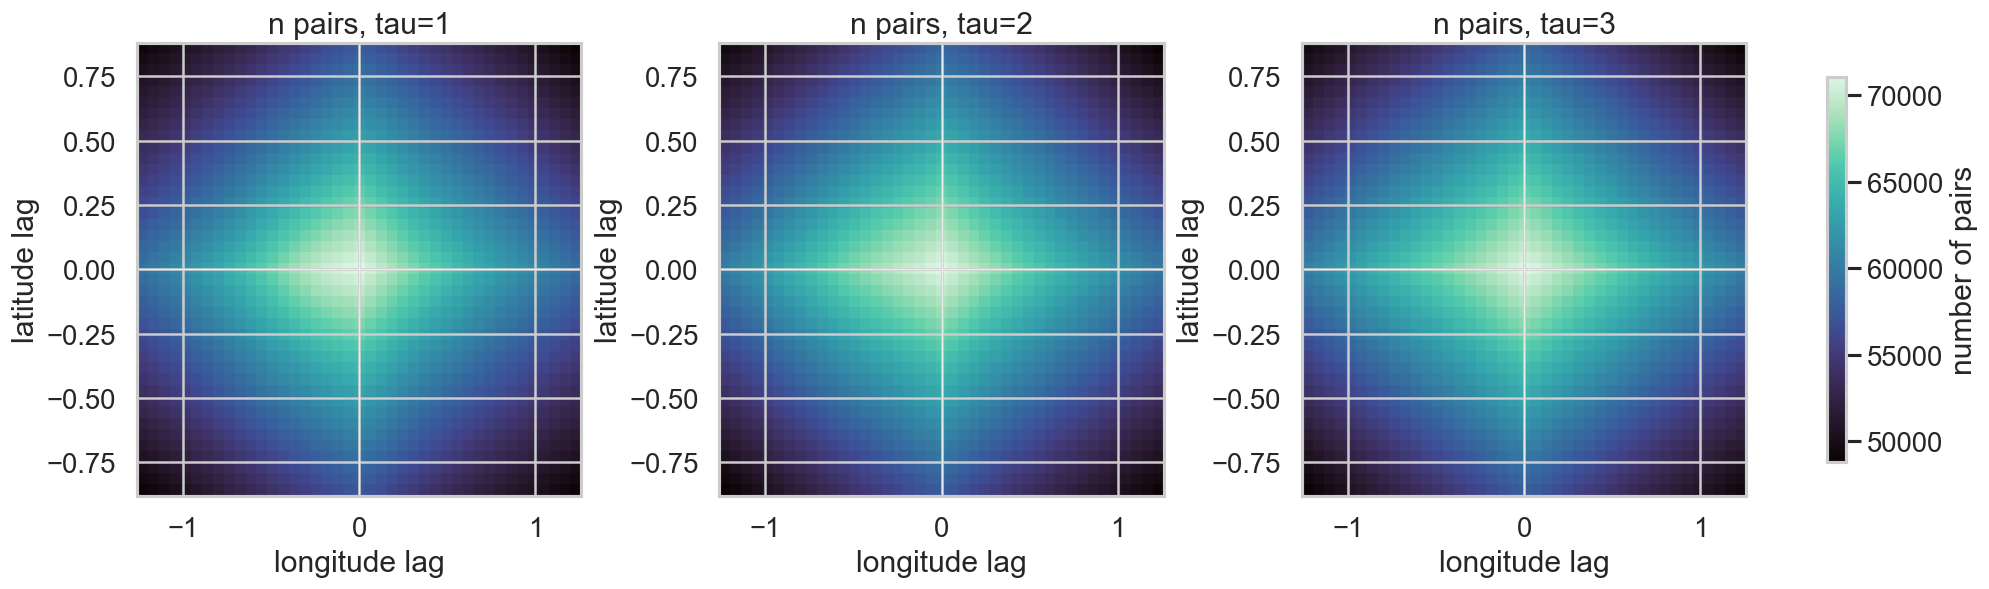

In [13]:
fig, axes = plot_pair_counts(surfaces, day=TARGET_DAY, save=True)
plt.show()


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526/advection_ridge_asymmetry_day01.png


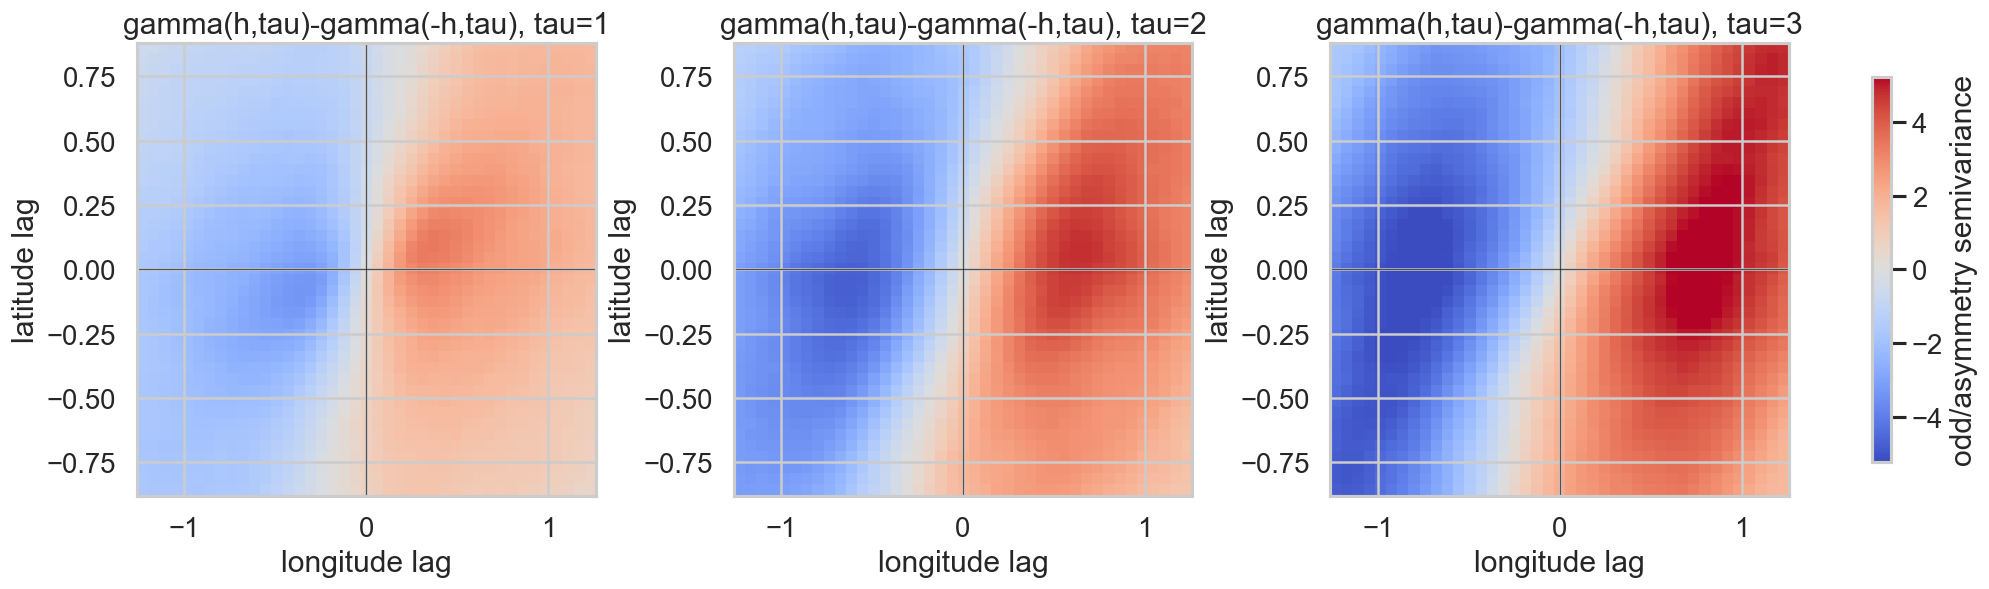

In [14]:
fig, axes = plot_asymmetry_surfaces(
    surfaces,
    day=TARGET_DAY,
    min_pair_count=MIN_PAIR_COUNT,
    save=True,
)
plt.show()


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/advection_ridge_052526/advection_metric_collapse_day01.png


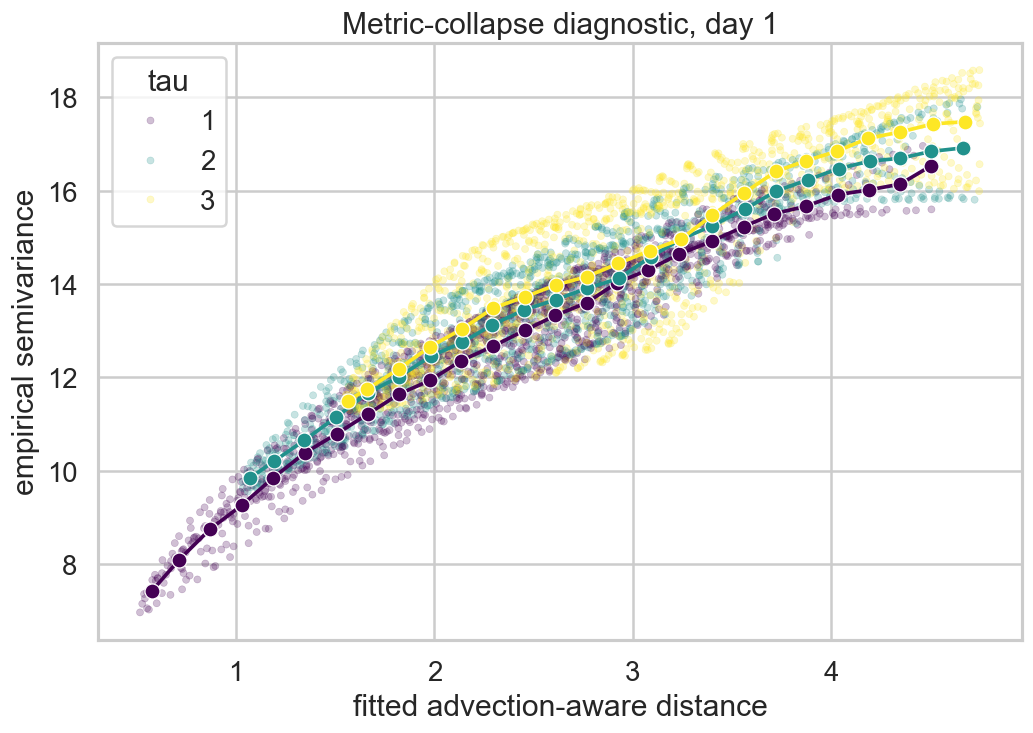

,tau,d_bin,d_mid,gamma_wmean,n_pairs
0,1,"(0.475, 0.633]",0.576242,7.425391,2076980
1,1,"(0.633, 0.791]",0.714245,8.095841,3368765
2,1,"(0.791, 0.95]",0.871725,8.757451,4119272
3,1,"(0.95, 1.108]",1.030790,9.267338,4732060
4,1,"(1.108, 1.266]",1.188629,9.854279,5440897


In [15]:
collapse_df = metric_collapse_dataframe(
    surfaces,
    estimates_df=estimates_df,
    day=TARGET_DAY,
    min_pair_count=MIN_PAIR_COUNT,
)

fig, ax, collapse_binned = plot_metric_collapse(
    collapse_df,
    day=TARGET_DAY,
    n_bins=30,
    save=True,
)
plt.show()

collapse_binned.head()


## Optional: monthly ridge summary

Set `RUN_MONTH_BATCH=True` to extract ridge locations for many days. This writes a compact CSV that can be plotted as a time series or compared with fitted daily advection.


In [16]:
RUN_MONTH_BATCH = False
DAYS_TO_SCAN = list(range(1, 32))

if RUN_MONTH_BATCH:
    estimates_df = load_estimates(ESTIMATE_CSV, year=YEAR)
    rows = []

    for day in DAYS_TO_SCAN:
        try:
            print(f'Processing day {day}...')
            dm = load_day_map(day, keep_ori=KEEP_ORI)
            ss = compute_advection_ridge_surfaces(
                dm,
                taus=TAUS,
                lat_offsets=lat_offsets,
                lon_offsets=lon_offsets,
                center_mode=CENTER_MODE,
                verbose=False,
            )
            est_row = get_estimate_row(estimates_df, day)
            for tau, surface in ss.items():
                ridge = extract_ridge(surface, smooth_sigma=SMOOTH_SIGMA, min_pair_count=MIN_PAIR_COUNT)
                model_pts = model_advection_points(est_row, tau)
                model_lon, model_lat = model_pts.get('fitted advection * tau', (np.nan, np.nan))
                rows.append({
                    'year': YEAR,
                    'month': MONTH,
                    'day': day,
                    'tau': tau,
                    'ridge_lat_lag': ridge['lat_lag'],
                    'ridge_lon_lag': ridge['lon_lag'],
                    'ridge_gamma_min': ridge['gamma_min'],
                    'ridge_n_pairs': ridge['n_pairs'],
                    'model_lat_lag': model_lat,
                    'model_lon_lag': model_lon,
                    'lat_step': surface['lat_step'],
                    'lon_step': surface['lon_step'],
                    'center_mode': CENTER_MODE,
                    'keep_ori': KEEP_ORI,
                })
        except Exception as exc:
            rows.append({
                'year': YEAR,
                'month': MONTH,
                'day': day,
                'tau': np.nan,
                'error': repr(exc),
            })
            print(f'  failed: {exc!r}')

    ridge_summary = pd.DataFrame(rows)
    out_csv = OUTPUT_DIR / f'advection_ridge_summary_{YEAR}_{MONTH:02d}.csv'
    ridge_summary.to_csv(out_csv, index=False)
    print(f'Saved {out_csv}')
    display(ridge_summary.head())


## Interpretation checklist

Use the plots in this order:

1. **Advection-ridge surfaces:** does the empirical minimum move in the same direction and magnitude as `advec * tau`?
2. **Pair counts:** are the minima supported by enough pairs, or are they edge artifacts?
3. **Odd/asymmetry surfaces:** is there lead-lag asymmetry that justifies a nonseparable/advection model?
4. **Metric collapse:** after using fitted `range_lat`, `range_lon`, `range_time`, and `advec`, do different `tau` values collapse onto one relationship?

If the ridge agrees but metric collapse fails, advection direction may be right but the range/time scaling is wrong. If metric collapse works only within latitude bands or tiles, the next step is a local ridge-vector map.
